# Quality control of sc/snRNA-seq

To perform quality control of single-cell or single-nuclei RNA sequencing (sc/snRNA-seq) we have the `dotools_py.pp.importer_py()` function. This function compiles different methods to process samples. We need to define a list of H5 files that have been generated from a mapping tool like CellRanger or STARsolo. If CellBender has been run, we can also provide the path to the H5 files generated by CellBender. Additionally, we need to provide the batch names for the samples, and additional metadata can be provided in the form of a dictionary.

The quality control involves filtering genes and cells:
- **Genes**: are removed on their expression levels. Genes expressed in low amount of cells are excluded. By default, we consider that a gene is excluded if it is expressed in less than 5 cells
- **Cells**: are removed based on different parameters, including: number of genes, mitochondrial content, doublets and number of UMI counts.
    - Mitochondrial content: cells with high mitochondrial content are excluded. We recomment assuming a maximum un 5 % for scRNA-seq and 3% for snRNA-seq
    - Doublets: we implemented three different approaches for the identification of neotypic doublets (i.e, doublets originating from the combination of two or more different cell-types). The available implementations are [scDblFinder](https://github.com/plger/scDblFinder), [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [Scrublet](https://github.com/swolock/scrublet).
    - Number of genes: cells are removed by absolute number of genes. A lower and upper threshold can be set.
    - Number of UMI counts: cells can be removed using two approaches: absolute or quantiles. A lower and upper threshold can be set and a combination of both approaches can be used (e.g., an absolute lower threshold and filter cells on the upper quantile).

After the quality control per sample, the individual samples will be combined into one AnnData object and log-normalisation, scaling and highly variable genes  will be calculated. To evaluate the quality control the distribution of total UMI, number of genes and mitochondrial genes per cell will be plotted in a violin plot before and after the quality control. These plots will be saved in the folders containing the H5 files. Additionally, we also keep track on the number of cells and genes that have been removed in each quality control step.

First, we start setting up the environment and loading the required libraries

In [1]:
# Set-Up
import dotools_py as do

2025-06-26 14:02:46,643 - Jupyter enviroment detected. Using "inline" backend


## Quality Control
To show how the quality control works, we are going to use a public dataset from 10X from human blood of healthy and donors with a malignant tumor. We get the raw and the filtered H5 files generated by 10X.

In [2]:
do.dt.example_10x('/Users/david/Downloads/Data10x')

2025-06-26 14:02:48,772 - Downloading data to /Users/david/Downloads/Data10x


In [3]:
paths = ['/Users/david/Downloads/Data10x/healthy/outs/filtered_feature_bc_matrix.h5',
         '/Users/david/Downloads/Data10x/disease/outs/filtered_feature_bc_matrix.h5']

adata = do.pp.importer_py(paths=paths,
                          ids=['batch1', 'batch2'],
                          metadata={'condition':['healthy', 'disease']},  # Additional metadata information
                          batch_key='batch',  # Column in obs to save batch information
                          remove_doublets=True,
                          doublet_tool='scDblFinder',  # Tool to identify neotypic doublets (Also available Scrublet and DoubletDetection)
                          min_genes_in_cell=300,
                          min_cells_with_genes=5,
                          cut_mt=5,
                          n_reads=10_000,
                          min_counts=500,  # Filter cells with less than 500 genes
                          high_quantile=95  # Filter cells with the top 5% high number of UMI counts
                          )

2025-06-26 14:02:54,842 - Reading batch1
reading /Users/david/Downloads/Data10x/healthy/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


2025-06-26 14:02:55,661 - Remove Cells with low number of genes
filtered out 14 cells that have less than 300 genes expressed
2025-06-26 14:02:55,727 - Remove Genes lowly expressed
filtered out 16694 genes that are detected in less than 5 cells
2025-06-26 14:02:55,816 - Remove cells with high MT-content
2025-06-26 14:02:55,828 - Remove cells based on nUMI counts
2025-06-26 14:02:55,852 - Finding Neotypic doublets


... storing 'batch' as categorical
... storing 'condition' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'sequence' as categorical


2025-06-26 14:02:55,932 - Running scDblFinder


...

2025-06-26 14:03:39,183 - Remove 24 doublets


Exporting to Python


2025-06-26 14:03:39,514 - Concatenating samples
2025-06-26 14:03:39,633 - Normalisation of the expression
normalizing counts per cell
    finished (0:00:00)
2025-06-26 14:03:39,655 - Scaling data
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
2025-06-26 14:03:39,805 - Finding Highly Variable Genes shared across samples
extracting highly variable genes


... storing 'doublet_class' as categorical
... storing 'doublet_score' as categorical


    finished (0:00:00)
2025-06-26 14:03:40,129 - Run PCA
computing PCA
    with n_comps=50
    finished (0:00:00)


In [4]:
adata

AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'

### Evaluation of Quality Control
We can now check the quality control plots for:

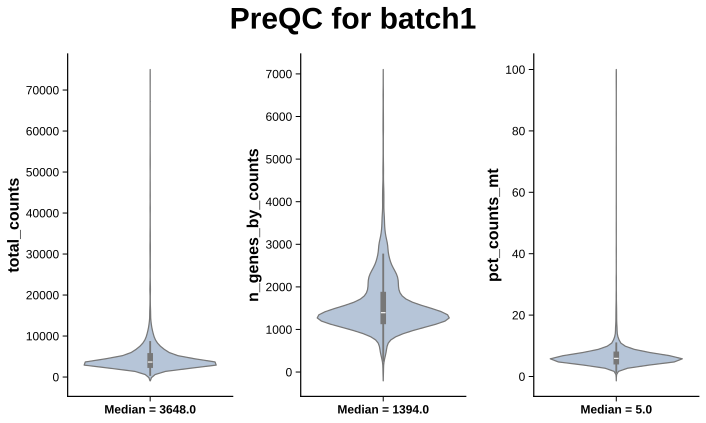

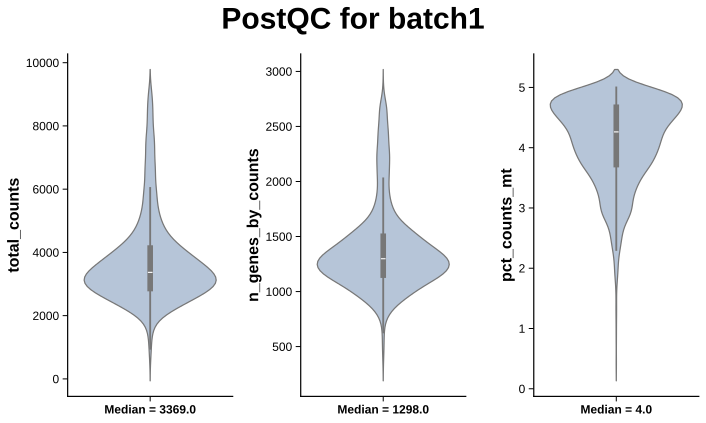

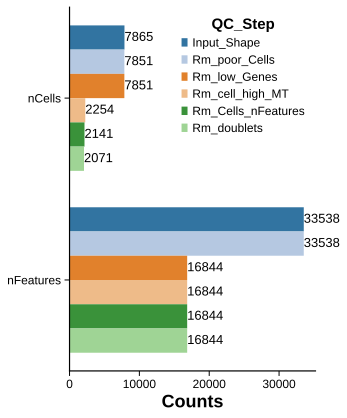

In [7]:
from IPython.display import display, HTML, SVG

files = [
    '/Users/david/Downloads/Data10x/healthy/outs/Vln_PreQC_batch1.svg',
    '//Users/david/Downloads/Data10x/healthy/outs/Vln_PostQC_batch1.svg',
    '/Users/david/Downloads/Data10x/healthy/outs/250626_QC_Metricsbatch1.svg'
]

display(SVG(files[0]),
        SVG(files[1]),
        SVG(files[2]),
        )


We can observe that the majority of cells were remove due to high mitochondrial content. Depending on the experimental set-up we might want to increase the threshold of mitochondrial content if we do not want to lose too many cells.

## Integration and clustering
After the quality control, we can now proceed to the batch correction and integration of the samples. For these, we can use different batch correction methods: Harmony, Scanorama, BBKNN, scVI and CCA from Seurat (v4 or v5 approach). After the integration of the samples, we run the Leiden algorithm to find clusters and generate the UMAP embeddings for visualisation.

In [8]:
do.tl.integrate_data(adata,
                     batch_key='batch',
                     hvg_batch=True, # Take HVG shared across samples
                     cca5=True,
                     resolution=0.5,  # Resolution for leiden algorithm
                     )

2025-06-26 14:04:16,653 - Computing HVGs
extracting highly variable genes
    finished (0:00:00)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:00)
2025-06-26 14:04:17,335 - Integration using CCA (Seurat v5 approach)
2025-06-26 14:04:17,347 - Preprocessing to export to Seurat
2025-06-26 14:04:17,401 - Running CCA Integration


Reading AnnData in R
Warning messages:
1: `PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
2: The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
3: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
Starting ACC in R environment...
Run CCA with v5
Centering and scaling data matrix
  |======================================================================| 100%
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 2705 anchors
Merging dataset 2 into 1
Extracting anchors for merged 

                          integratedcca_1 integratedcca_2 integratedcca_3
AAACCCAGTGCATTTG-1-batch1      -29.678138      -0.3656399        4.232620
AAACCCATCTCAACGA-1-batch1        4.476557       1.1619279        4.089299
AAACCCATCTCTCGAC-1-batch1        4.177654       1.4757112        3.667988
2025-06-26 14:04:37,772 - Loading corrected matrix


0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Integrating data
Warning messages:
1: Input is a v3 assay and `split()` only works for v5 assays; converting
• to a v5 assay 
2: The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
Preparing to export to python...
Saving data in 
/tmp/CCA_fcb5155723f64e459cce027cc8a9d61b/adata_hvg_seurat_AnchorIntegration.csv


2025-06-26 14:04:37,949 - Finding neighbors
computing batch balanced neighbors
	finished (0:00:00)
2025-06-26 14:04:38,872 - Run UMAP
computing UMAP
    finished (0:00:01)
2025-06-26 14:04:40,431 - Clustering cells using Leiden (resolution 0.5)
running Leiden clustering
    finished (0:00:00)


In [9]:
adata

AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score', 'leiden'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_CCA', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'distances', 'connectivities'

 We can observe, that after the integration we have `X_CCA` in `obsm`. This is the CCA matrix after dimensionality reduction. Contrary to the approach in Seurat4 where  the dimensions of this matrix is  n_cells x n_hvg, in this case the dimension is n_cells x 50

In [10]:
adata.obsm['X_CCA'].shape

(2801, 50)

### Evaluation of integration
We can now visualise the integrated object and the identified clusters:

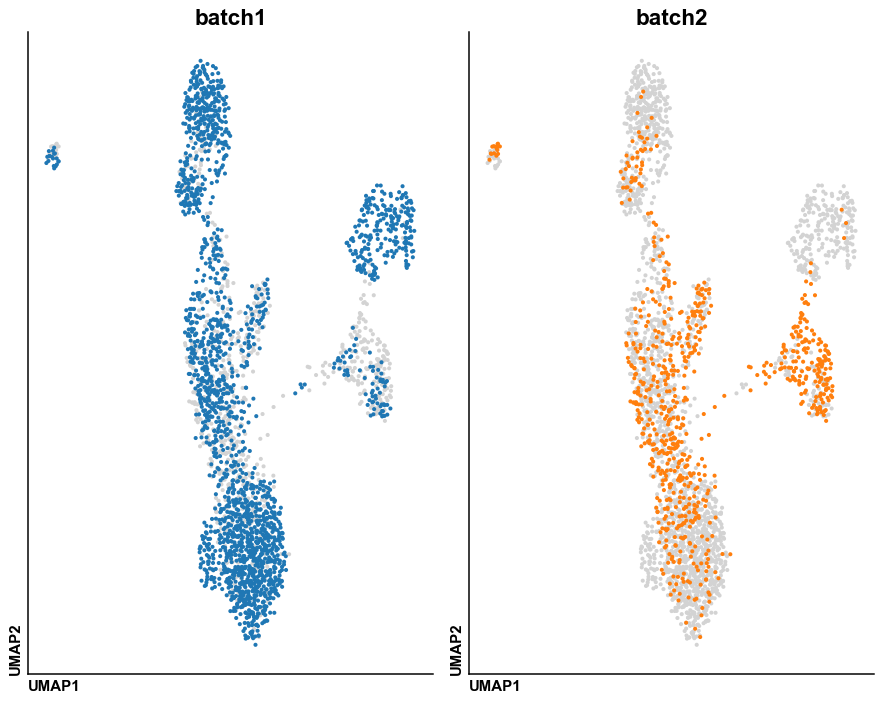

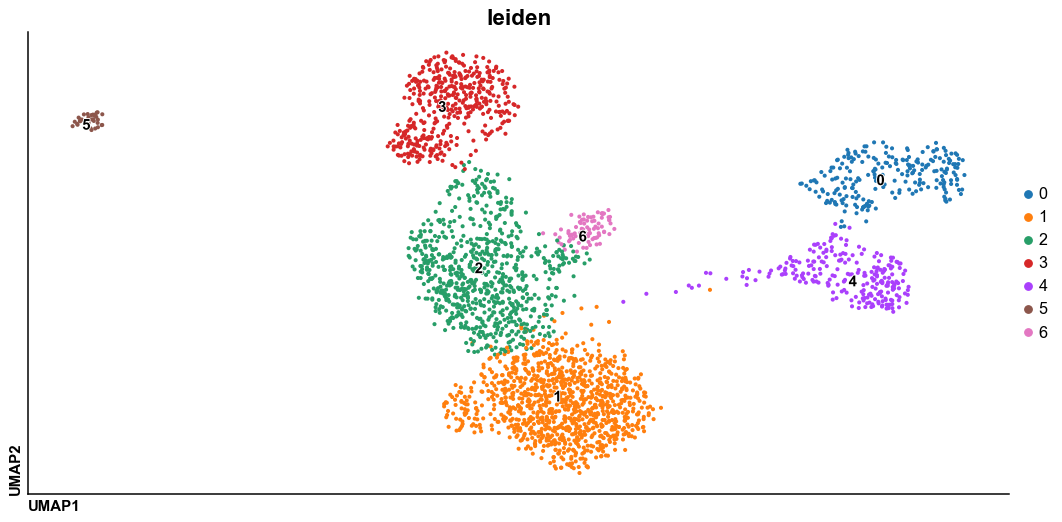

In [11]:
do.pl.split_embeddding(adata, 'batch')
do.pl.umap(adata, 'leiden', labels='leiden')

## Semi-automatic annotation with CellTypist

We also have the possibility to perform a semi-automatic annotation using [CellTypist](https://www.celltypist.org/). In this case, we use the  `Adult_COVID19_PBMC.pkl` model.

In [12]:
adata = do.tl.auto_annot(adata, 'leiden', model='Healthy_COVID19_PBMC.pkl', convert=False, pl_cell_prob=True)

🔬 Input data has 2801 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 3323 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


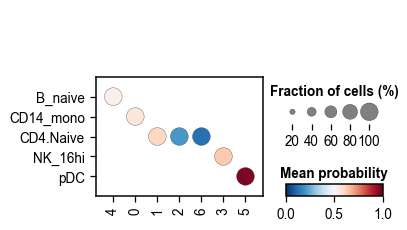

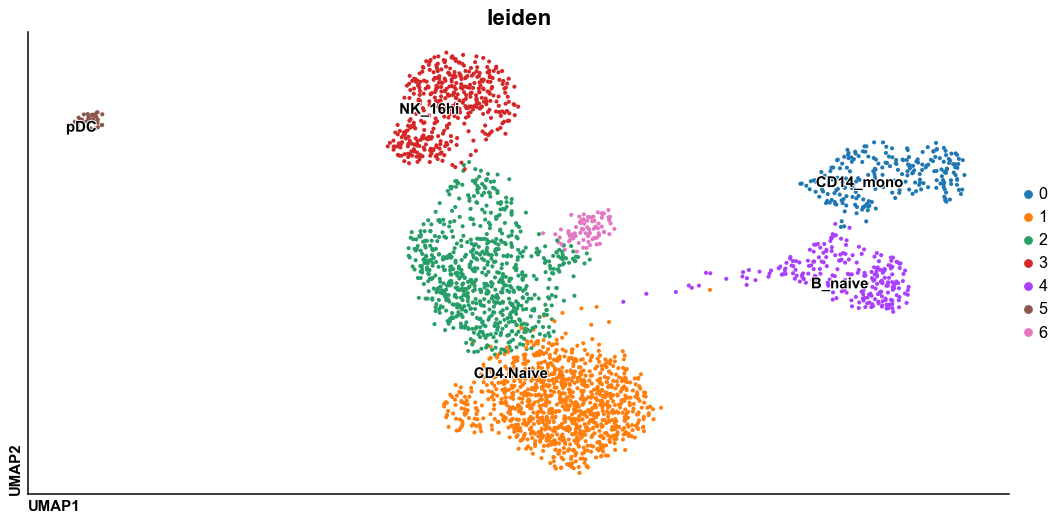

In [13]:
do.pl.umap(adata, 'leiden', labels='autoAnnot')

Besides the semi-automatic annotation, we should also validate the findings with  known markers for these celltypes.


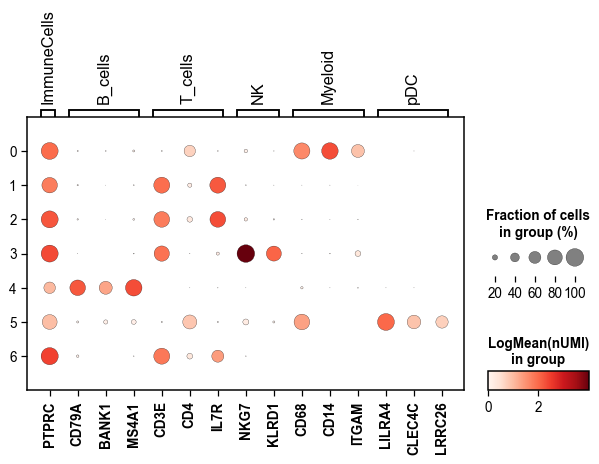

In [14]:
markers = {'ImmuneCells': ['PTPRC'],
           'B_cells': ['CD79A', 'BANK1', 'MS4A1'],
           'T_cells': ['CD3E', 'CD4', 'IL7R'],
           'NK': ['NKG7', 'KLRD1'],
           'Myeloid': ['CD68', 'CD14', 'ITGAM'],
           'pDC': ['LILRA4', 'CLEC4C', 'LRRC26']}

do.pl.dotplot(adata, 'leiden', markers, swap_axes=False)

Overall we can see an agreement with the annotation and can continue with the annotation.

... storing 'annotation' as categorical


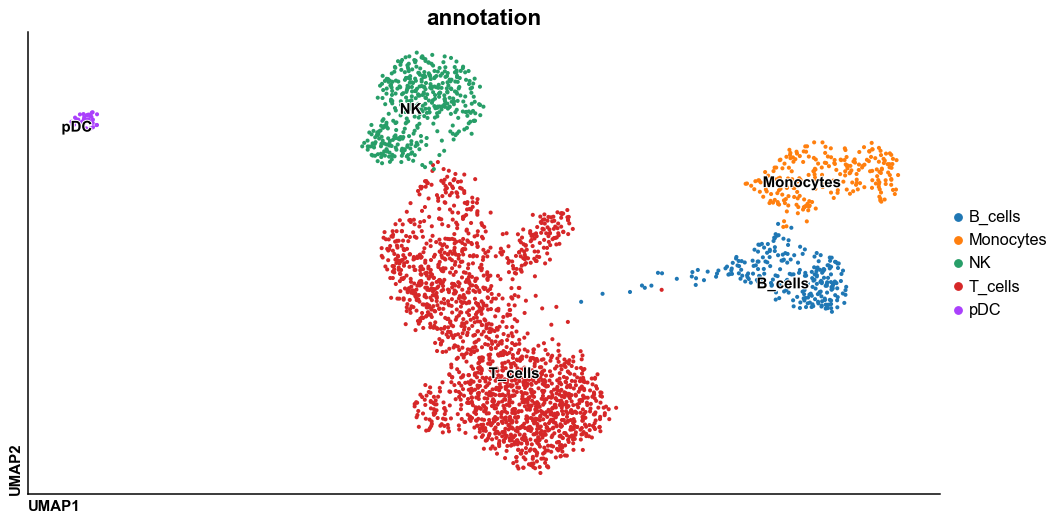

In [15]:
adata.obs['annotation'] = adata.obs.leiden.map({'0': 'Monocytes', '1': 'T_cells', '2': 'T_cells', '3': 'NK',
                                                '4': 'B_cells', '5': 'pDC', '6': 'T_cells'})
do.pl.umap(adata, 'annotation', labels='annotation')

## Evaluate changes in cell population
After the identification of the celltype populations, we can also evaluate if there are significant changes in these populations in the healthy and diseased condition using [scanpro](https://github.com/loosolab/scanpro).

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.3 seconds
2025-06-26 14:06:01,404 - There are 3 populations with a significant change


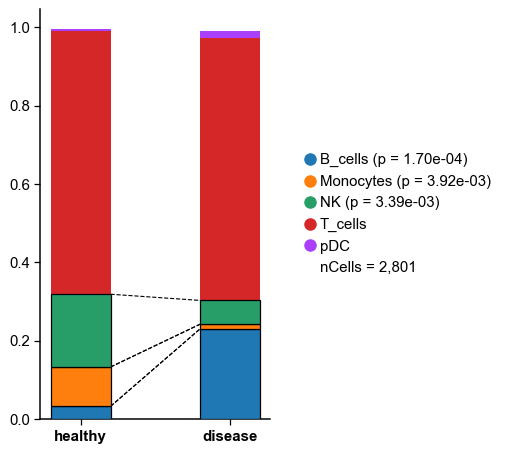

In [16]:
do.pl.cell_props(adata,
                 annot_key='annotation',
                 cond_key='condition',
                 batch_key='batch',
                 transform='arcsin',  # Produce more accurate results for simulated data
                 cond_order=['healthy', 'disease'])

Cell populations with a significant change are connected by discontinued lines and the p-value is indicated in the legend. In this case, we see a significant change in B cells assuming a significant threshold of 0.05.

## Reclustering of a cell population

If we are interested in specific states for a celltypes, we can also perform re-clustering. In this case, we are going to focus on the biggest cluster, the T cells.

2025-06-26 14:06:06,323 - Reclustering using CCA5 approach
computing batch balanced neighbors
	finished (0:00:00)
computing UMAP
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)


🧬 Number of genes in the original model: 3874
✅ Conversion done! Number of genes in the converted model: 3156
🔬 Input data has 1868 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 4 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'annotation_recluster' as categorical


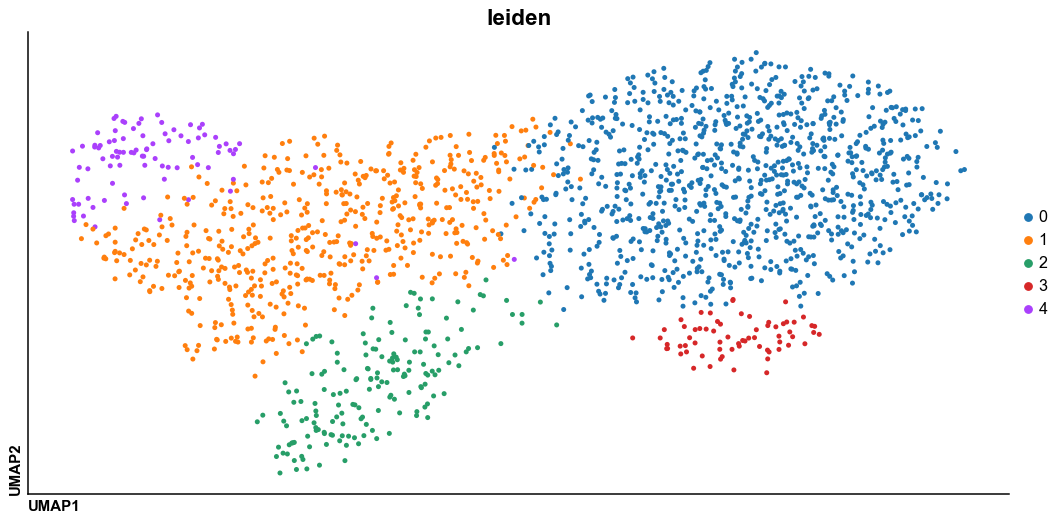

In [17]:
tcell = do.tl.reclustering(adata,
                           cluster_key='annotation',  # Metadata column with clusters
                           batch_key='batch',  # Metadata column with batch information
                           recluster_apporach='CCA5',  # Integration approach used
                           use_clusters=['T_cells'],  # Cluster we want to re-cluster
                           use_rep='X_CCA',  # representation to use
                           get_subset=True,  # Get AnnData of T_cells re-clusters
                           resolution=0.5,
                           )
do.pl.umap(tcell, 'leiden')

We identified 3 clusters, to evaluate if there are subtypes of T_cells we can identify the top markers for each cluster.

In [18]:
do.tl.rank_genes_groups(tcell, groupby='leiden', method='wilcoxon', tie_correct=True, pts=True)
table = do.tl.generate_results(tcell)
table_filt = table[(table.log2fc > .25) & (table.padj < 0.05)]

for group in table_filt.group.unique():
    display(table_filt[table_filt.group == group].head(10))

ranking genes
    finished (0:00:04)


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
0,0,RPS3A,25.127644,0.599066,2.481195e-139,2.297214e-135,0.998994,1.000000
1,0,RPS13,24.803030,0.664110,8.315051e-136,5.132326e-132,0.998994,0.998856
2,0,RPL30,23.232048,0.460067,2.160653e-119,8.001763e-116,1.000000,1.000000
3,0,RPL32,22.789486,0.469136,5.829676e-115,1.799135e-111,1.000000,1.000000
4,0,RPS23,22.084505,0.484616,4.454049e-108,1.178223e-104,1.000000,0.998856
5,0,RPS27A,21.998020,0.449319,3.008218e-107,6.962897e-104,1.000000,0.998856
6,0,RPL11,20.805342,0.408917,3.871840e-96,7.169487e-93,1.000000,1.000000
7,0,RPL19,20.226261,0.411356,5.750025e-91,8.872767e-88,1.000000,1.000000
8,0,RPL39,19.286072,0.355048,7.031686e-83,1.001582e-79,1.000000,1.000000
9,0,RPL35A,18.808563,0.426057,6.425589e-79,7.932175e-76,0.997988,1.000000


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
18517,1,ANXA1,20.314821,2.181956,9.509415e-92,1.760858e-87,0.746789,0.276644
18518,1,ITGB1,18.996435,2.104041,1.825315e-80,1.689968e-76,0.609174,0.171580
18519,1,S100A11,18.412619,1.686280,1.040674e-75,6.423388e-72,0.730275,0.303099
18520,1,S100A4,18.328836,1.627297,4.872105e-75,2.255419e-71,0.860550,0.526077
18521,1,B2M,17.094379,0.371174,1.634268e-65,6.052348e-62,1.000000,0.999244
18522,1,KLRB1,15.596785,2.118289,7.655423e-55,1.771943e-51,0.383486,0.083900
18523,1,KLF6,14.865000,1.159289,5.561529e-50,1.144254e-46,0.816514,0.428571
18524,1,ANXA2,14.828723,1.907698,9.553373e-50,1.768998e-46,0.394495,0.095238
18525,1,AHNAK,14.699397,1.546712,6.503650e-49,1.094801e-45,0.506422,0.160998
18526,1,SH3BGRL3,14.395431,0.851666,5.527923e-47,8.435152e-44,0.932110,0.808012


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
37034,2,IKZF2,21.125038,3.805256,4.682538e-99,8.670655e-95,0.494186,0.037736
37035,2,CTLA4,18.665995,3.305368,9.361478e-78,8.667325e-74,0.563953,0.079599
37036,2,RTKN2,18.138346,3.520152,1.587375e-73,9.797808e-70,0.453488,0.048939
37037,2,FOXP3,17.565403,4.534667,4.534644e-69,2.099200e-65,0.296512,0.015920
37038,2,TIGIT,17.325882,2.841039,3.000626e-67,1.111252e-63,0.546512,0.086085
37039,2,CYTOR,16.069590,2.763218,4.168396e-58,1.102660e-54,0.546512,0.107901
37040,2,TNFRSF9,15.748761,5.896300,7.004048e-56,1.441044e-52,0.191860,0.005307
37041,2,ICA1,14.964748,2.802461,1.247955e-50,1.925698e-47,0.377907,0.051297
37042,2,PMAIP1,14.884576,2.753129,4.151085e-50,5.912742e-47,0.534884,0.118514
37043,2,MIR4435-2HG,14.799731,3.143948,1.470692e-49,1.945200e-46,0.366279,0.050118


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
55551,3,LINC02446,33.625294,6.106173,7.163058e-248,1.326383e-243,0.865672,0.012771
55552,3,CD8B,29.547571,5.223254,7.056251e-192,6.533030e-188,0.925373,0.032204
55553,3,CD8A,27.336941,4.777964,1.544103e-164,9.530718e-161,0.791045,0.025541
55554,3,CD8B2,15.974483,6.725996,1.924413e-57,8.908590e-54,0.179104,0.001666
55555,3,CTSW,12.569304,2.448422,3.114532e-36,1.153436e-32,0.686567,0.134370
55556,3,S100B,11.802361,5.939208,3.795104e-32,1.171232e-28,0.134328,0.003331
55557,3,FCER1G,11.094094,3.142859,1.340113e-28,3.544981e-25,0.283582,0.026097
55558,3,FBLN2,10.209299,4.782906,1.801609e-24,4.170049e-21,0.104478,0.002776
55559,3,SYNGR1,9.198175,6.744767,3.640804e-20,6.905295e-17,0.059701,0.000555
55560,3,SFRP5,9.195598,6.605827,3.729165e-20,6.905295e-17,0.059701,0.000555


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
74068,4,GZMK,23.024679,4.332928,2.638681e-117,4.886046e-113,0.800000,0.068054
74069,4,NKG7,22.877296,6.231580,7.819954e-116,7.240104e-112,0.566667,0.026434
74070,4,CCL5,22.522549,5.252087,2.495932e-112,1.540572e-108,0.700000,0.051181
74071,4,CST7,18.731548,3.968807,2.738357e-78,1.267654e-74,0.677778,0.077053
74072,4,GZMA,18.401237,4.262382,1.283988e-75,4.755119e-72,0.566667,0.051744
74073,4,EOMES,17.671257,5.969410,6.982346e-70,2.154868e-66,0.244444,0.004499
74074,4,PLEK,15.627650,4.631486,4.718850e-55,1.248271e-51,0.266667,0.011249
74075,4,TRGC2,13.567121,3.456810,6.273896e-42,1.452172e-38,0.366667,0.037683
74076,4,KLRD1,12.145414,4.693018,6.067454e-34,1.248345e-30,0.166667,0.007312
74077,4,TRGC1,12.054544,4.148727,1.835440e-33,3.398685e-30,0.233333,0.017998


From the list of markers, cluster 2 seems to express markers for T regulatory cells. while cluster 3 seems to be enriched in cytotoxic markers. We can visualise the distribution of these genes.

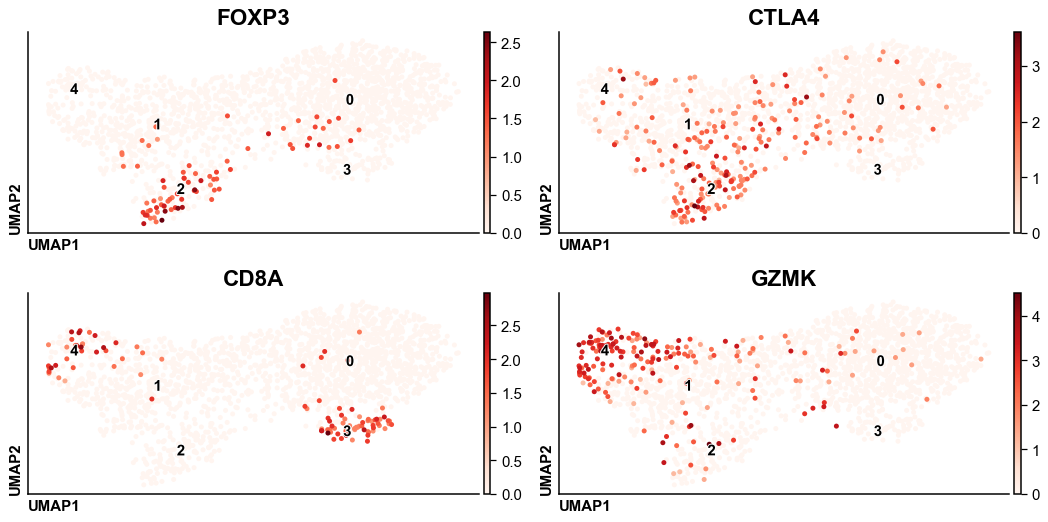

In [19]:
do.pl.umap(tcell, ['FOXP3', 'CTLA4', 'CD8A', 'GZMK'], ncols=2, labels='leiden')

From this list of markers, we can see that cluster 1 is enriched for cytotoxic markers. We can transfer this annotation to our original object and evaluate again changes in the cell population.

... storing 'annotation_recluster' as categorical


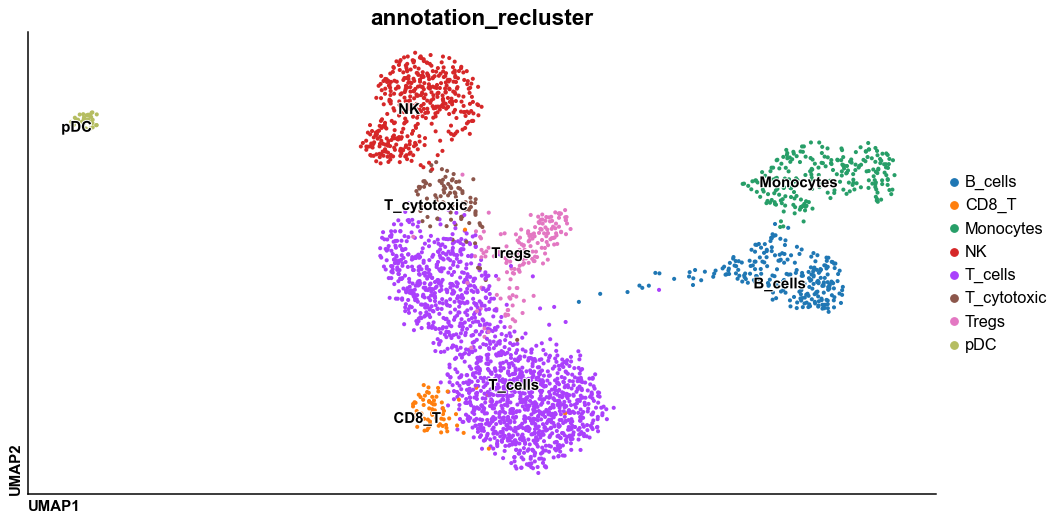

In [20]:
tcell.obs['annotation_recluster'] = tcell.obs.leiden.map({'0': 'T_cells', '1': 'T_cells', '2':'Tregs', '3': 'CD8_T', '4': 'T_cytotoxic'})
adata.obs['annotation_recluster'] = adata.obs['annotation'].copy()
do.utility.transfer_labels(adata_original=adata,
                           adata_subset=tcell,
                           original_key='annotation_recluster',
                           subset_key='annotation_recluster',
                           original_labels=['T_cells']
                           )
do.pl.umap(adata, 'annotation_recluster', labels='annotation_recluster')

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.33 seconds
2025-06-26 14:06:29,622 - There are 5 populations with a significant change


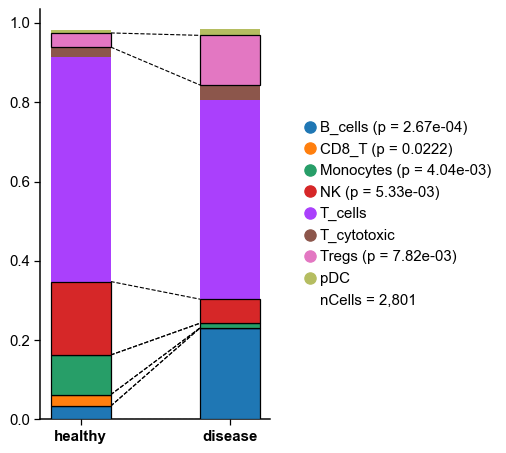

In [21]:
do.pl.cell_props(adata,
                 annot_key='annotation_recluster',
                 cond_key='condition',
                 batch_key='batch',
                 transform='arcsin',
                 cond_order=['healthy', 'disease']
                 )

We can see that even though there is a decrease in the proportion of T_cytotoxic, the change is not significant.

## Gene Ontology analysis

We can also evaluate which biological processes are enriched in a celltype in each condition by performing gene ontology analysis. First, we need to identified differentially expressed genes. We are going to focus on T cells. We can use `do.tl.go_analysis()` to run gene set analysis using the enrichR API. This function, will split differentially express genes in up- and down-regulated and run the analysis for each set.

In [68]:
tcell = adata[adata.obs.annotation == 'T_cells']
do.tl.rank_genes_groups(tcell, groupby='condition', method='wilcoxon', tie_correct=True, pts=True,
                        reference='healthy', groups=['disease'])
table = do.tl.generate_results(tcell)
df  = do.tl.go_analysis(table,
                        gene_key='GeneName',
                        pval_key='padj',
                        log2fc_key='log2fc',
                        log2fc_cutoff=0.25,  # It will take -0.25 and +0.25
                        specie='Human',
                        go_catgs=['GO_Biological_Process_2023'])
df

ranking genes
    finished (0:00:01)
2025-06-18 10:43:00,559 - Running GSA on Up- and Down-regulated genes


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,state
0,GO_Biological_Process_2023,Regulation Of Apoptotic Process (GO:0042981),118/705,1.315993e-11,5.040440e-08,0,0,2.124351,5.322316e+01,TFRC;ARL6IP1;CIB1;FAIM2;PARK7;TNF;IKZF3;CCND2;...,enriched
1,GO_Biological_Process_2023,Regulation Of Gene Expression (GO:0010468),167/1127,2.399638e-11,5.040440e-08,0,0,1.853908,4.533383e+01,ZNF331;TFRC;NAB1;NAB2;JMJD1C;RORA;PRDM2;AHR;PA...,enriched
2,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,66/320,8.284026e-11,1.160040e-07,0,0,2.713239,6.298543e+01,IL21;ITK;CD40;RORA;PTPN22;PARK7;TNF;PNP;PDE4B;...,enriched
3,GO_Biological_Process_2023,Regulation Of B Cell Proliferation (GO:0030888),20/44,2.022155e-10,1.862407e-07,0,0,8.583428,1.915966e+02,IL21;IL10;LYN;VAV3;CD74;CD40;MEF2C;TFRC;TNFRSF...,enriched
4,GO_Biological_Process_2023,Positive Regulation Of Apoptotic Process (GO:0...,58/270,2.216624e-10,1.862407e-07,0,0,2.850159,6.335866e+01,TOP2A;PRR7;BTG1;CTSV;TNF;ADAMTSL4;CTSL;CASP3;P...,enriched
...,...,...,...,...,...,...,...,...,...,...,...
4394,GO_Biological_Process_2023,Sensory Perception Of Smell (GO:0007608),2/230,9.999951e-01,9.999960e-01,0,0,0.047515,2.307267e-07,OR4D1;MKKS,depleted
4395,GO_Biological_Process_2023,Sodium Ion Transmembrane Transport (GO:0035725),1/82,9.999955e-01,9.999960e-01,0,0,0.067441,3.041719e-07,SLC9A3,depleted
4396,GO_Biological_Process_2023,Potassium Ion Transmembrane Transport (GO:0071...,4/137,9.999956e-01,9.999960e-01,0,0,0.163943,7.240476e-07,SLC9A3;KCNQ1;TMEM175;SLC12A9,depleted
4397,GO_Biological_Process_2023,Potassium Ion Transport (GO:0006813),3/122,9.999957e-01,9.999960e-01,0,0,0.137493,5.922716e-07,SLC9A3;KCNQ1;TMEM175,depleted


We can visualise the top terms enriched in each condition with `do.pl.split_bar_gsea()`. But we need to do a pre-filtering to only consider significant terms.

2025-06-18 10:43:13,508 - !!! Assuming GO Terms are preprocessed (Only Significant terms included)


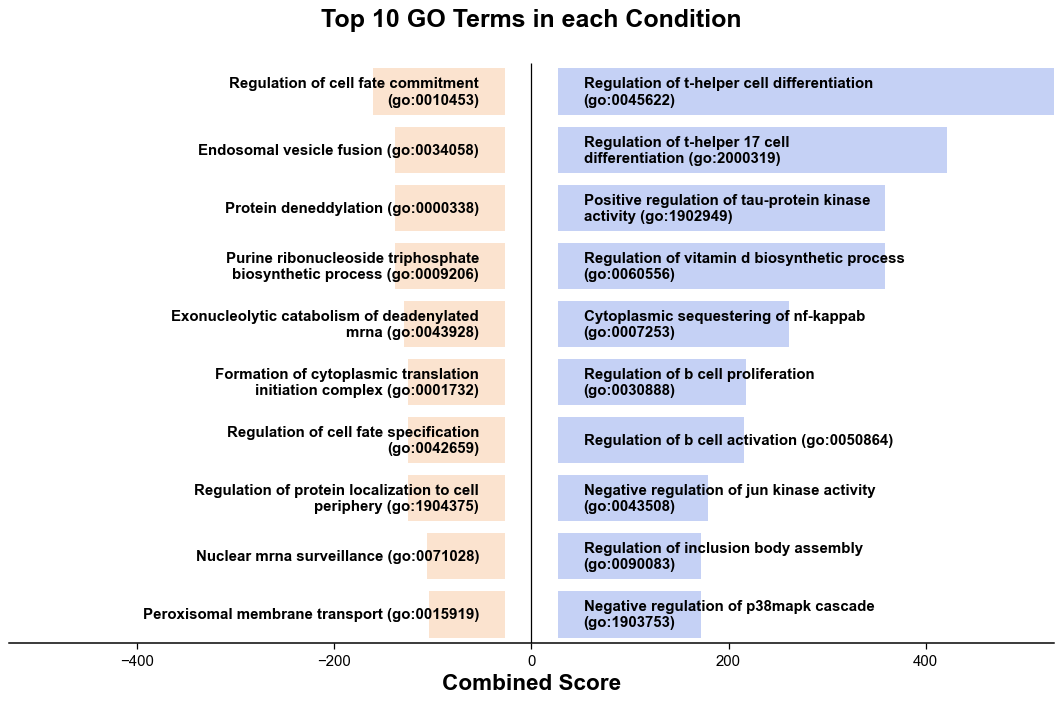

In [69]:
df_filt = df[df['Adjusted P-value'] < 0.05]
do.pl.split_bar_gsea(df_filt,
                     term_col='Term',
                     col_split='Combined Score',  # Column to use for the x-axis
                     cond_col='state',  # Column that splits the up and down-regulated terms
                     pos_cond='enriched',  # value in cond_col that should be in the positive axis
                     )

In [22]:
adata.write('/Users/david/Downloads/Data10x/adata.h5ad')

In [23]:
!pip list

Package                   Version      Editable project location
------------------------- ------------ ---------------------------------------------------
absl-py                   2.2.2
adjustText                1.3.0
aiobotocore               2.21.1
aiohappyeyeballs          2.6.1
aiohttp                   3.11.16
aioitertools              0.12.0
aiosignal                 1.3.2
anndata                   0.11.4
annotated-types           0.7.0
annoy                     1.17.3
anyio                     4.7.0
appnope                   0.1.2
archspec                  0.2.3
argon2-cffi               21.3.0
argon2-cffi-bindings      21.2.0
array_api_compat          1.11.2
asciitree                 0.3.3
asttokens                 3.0.0
async-lru                 2.0.4
async-timeout             5.0.1
attrs                     25.3.0
babel                     2.16.0
backports.tarfile         1.2.0
bbknn                     1.6.0
beautifulsoup4            4.12.3
bleach                    6.2.0
